In [2]:
!pip install xlrd
!pip install openpyxl
import pandas as pd
import unicodedata
from pathlib import Path

Plusieurs jeux de données sont mobilisés ci-dessous : 
- les résultats des élections municipales
- les listes des municipales, pour récupérer les couleurs politiques de tous les élus municipaux pour les interco
- la liste des présidents d'interco, pour donner une couleur politique aux interco
- la correspondance entre EPCI et communes appartenant à l'interco
- la correspondance entre code Insee et code postal

In [3]:
#creation d'une fonction pour détecter là où débute vraiment le fichier
def detecter_ligne_header(fichier, mot_cle="Critère d'export", limite=15):
    preview = pd.read_excel(fichier, header=None, nrows=limite)

    for idx, row in preview.iterrows():
        if mot_cle in row.astype(str).values:
            return idx
    return 0

In [4]:
def simplifier_prenom(text):
    if pd.isna(text):
        return None   # ou "" ou text
    # Normalise en forme NFD (décompose les accents)
    text_normalized = unicodedata.normalize('NFD', text)
    # Garde seulement les caractères ASCII (supprime les accents)
    text_ascii = text_normalized.encode('ascii', 'ignore').decode('utf-8')
    text_clean = text_ascii.replace('-', ' ')
    return text_clean

### Importation données listes municipales 2014

In [5]:
# Dossier contenant uniquement les fichiers à importer
dossier_listes_2014 = Path("/home/onyxia/work/projet3A/donnees_electorales/donnees listes municipales 2014")

# Liste de tous les fichiers du dossier
fichiers_2014 = dossier_listes_2014.iterdir()

dfs = []

for f in fichiers_2014:
    ligne_header = detecter_ligne_header(f)
    df = pd.read_excel(f, header=ligne_header)
    df["source"] = f.name  # optionnelle
    dfs.append(df)

df_listes_muni_2014 = pd.concat(dfs, ignore_index=True)

print("Dimensions :", df_listes_muni_2014.shape)

Dimensions : (520074, 16)


On garde uniquement les infos sur la ville, la liste et le numéro dans la liste de chaque personne sur une liste municipale

In [6]:
df_listes_muni_2014.drop(labels = [ "Critère d'export", 'Libellé du département','Libellé commune', 'N° Panneau Liste', 'Code Dépôt',
       'Libellé abrégé liste', 'Libellé Etendu Liste',
       'Sexe', 'Nationalité',
       'Candidat au conseil communautaire', 'source'],axis = 1, inplace=True)

Importation du jeu de données contenant les résultats de toutes les élections (sauf municipales de 2014 qui sont manquantes)

In [7]:
all_elections = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/candidats_results.txt", sep=";")
#mini modif manuelle à cause d'une erreur
all_elections.loc[22340396, 'Binôme'] = all_elections.loc[22160435, 'Binôme']

/tmp/ipykernel_360698/3451900702.py:1: DtypeWarning: Columns (2,4,6,7,8,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  all_elections = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/candidats_results.txt", sep=";")


In [8]:
muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",
    encoding="latin-1", skiprows=17, header= None)
muni_2014.columns = ['id_tour', 'Code du département', 'Code de la commune', 'Nom de la commune',
'Code du b.vote', 'Inscrits', 'Votants', 'Exprimes', 'num liste', 'Prénom', 'Nom', 'Nuance', 'Voix']
muni_2014['id_tour'] = "t" + muni_2014['id_tour'].astype(str)
print(muni_2014.shape)

#On supprime tous les candidats de liste sans nuance politique !!! 
muni_2014 = muni_2014[muni_2014['Nuance'] != "NC"]
print(muni_2014.shape)

/tmp/ipykernel_360698/874599522.py:1: DtypeWarning: Columns (1,4) have mixed types. Specify dtype option on import or set low_memory=False.
  muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",


(692029, 13)
(206898, 13)


## Etape initiale : constituer une liste des nuances de tous les candidats

##### Traitement des données des candidats aux départementales, qui ont un format "binome"

In [9]:
elec_binome = all_elections[all_elections["Binôme"].notna()]
liste_elec_binome = elec_binome['id_election'].unique()
election_dep = all_elections[all_elections['id_election'].isin(liste_elec_binome)]
election_dep.drop_duplicates(subset=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], inplace=True)
election_dep = election_dep[["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"]]
election_dep[["candidat1", "candidat2"]] = election_dep["Binôme"].str.split(" et ", expand=True)

# Enlever les titres "M" ou "Mme" au début
election_dep["candidat1"] = election_dep["candidat1"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)
election_dep["candidat2"] = election_dep["candidat2"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)

election_dep[[ "nom1", "prenom1"]] = election_dep["candidat1"].str.split(" ", n=1, expand=True)
election_dep["prenom1"] = election_dep["prenom1"].str.lower()
election_dep[[ "nom2","prenom2"]] = election_dep["candidat2"].str.split(" ", n=1, expand=True)
election_dep["prenom2"] = election_dep["prenom2"].str.lower()

election_dep_long = pd.wide_to_long(election_dep, 
                          stubnames=["prenom", "nom"], 
                          i=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], 
                          j="num_binôme",   # nouveau suffixe qui indiquera 1 ou 2
                          sep="")    # pas de séparateur entre stubname et numéro

# Réinitialiser l'index pour obtenir un DataFrame classique
election_dep_long = election_dep_long.reset_index()
election_dep_long['Nuance'] = election_dep_long['Nuance'].str.replace(r'^BC-', '', regex=True)
election_dep_long.drop(['Binôme', 'num_binôme', 'candidat1', 'candidat2'], axis = 1, inplace= True)

/tmp/ipykernel_360698/678289474.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  election_dep.drop_duplicates(subset=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], inplace=True)


##### Traitement des candidats hors municipales et départementales

In [10]:
election_hors_dep = all_elections[~all_elections['id_election'].isin(liste_elec_binome)]
election_hors_dep_et_muni = election_hors_dep[election_hors_dep["id_election"].str.contains("muni", case=False, na=False)]
election_hors_dep_et_muni = election_hors_dep_et_muni[['id_election', 'id_brut_miom', 'Code du département', 'Nom', 'Prénom', 'Nuance']]

In [11]:
election_dep_long.rename(columns={'prenom': 'Prénom'}, inplace=True)
election_dep_long.rename(columns={'nom': 'Nom'}, inplace=True)
election_dep_long.rename(columns={'Code du département': 'dep'}, inplace=True)
election_hors_dep_et_muni.rename(columns={'Code du département': 'dep'}, inplace=True)
liste_candidats_nuance_hors_muni = pd.concat([election_dep_long, election_hors_dep_et_muni], ignore_index=True)
liste_candidats_nuance_hors_muni['annee'] = liste_candidats_nuance_hors_muni['id_election'].str[:4]
liste_candidats_nuance_hors_muni.head()

,id_election,id_brut_miom,dep,Nuance,Prénom,Nom,annee
0,2021_dpmt_t2,01001_0001,01,UCD,patricia,CHMARA,2021
1,2021_dpmt_t2,01001_0001,01,UCD,patrick,MATHIAS,2021
2,2021_dpmt_t2,01002_0001,01,UG,fabrice,PEREYRON,2021
3,2021_dpmt_t2,01002_0001,01,UG,marie-céline,RAY,2021
4,2021_dpmt_t2,01004_0001,01,UG,fabrice,PEREYRON,2021


### On s'intéresse au score des municipales

In [12]:
muni_2014['id_brut_miom'] = muni_2014['Code du département'].astype(str) + muni_2014['Code de la commune'].astype(str) + "_" + muni_2014['Code du b.vote'].astype(str)
muni_2014['id_election'] = "2014_muni_" + muni_2014['id_tour'].astype(str)
muni_2014['ident_election_ville'] = muni_2014["id_brut_miom"].str[:-5]

In [13]:
donnees_restreintes_muni = all_elections[all_elections["id_election"].str.contains("muni", case=False, na=False)]
donnees_restreintes_muni['ident_election_ville'] = donnees_restreintes_muni["id_brut_miom"].str[:5]

#à nouveau, on enlève les candidats où il n'y a pas de nuance politique 
print(donnees_restreintes_muni.shape)
donnees_restreintes_muni = donnees_restreintes_muni[donnees_restreintes_muni['Nuance'] != 'NC']
print(donnees_restreintes_muni.shape)
donnees_restreintes_muni = donnees_restreintes_muni[donnees_restreintes_muni['Nuance'] != 'LNC']
print(donnees_restreintes_muni.shape)

/tmp/ipykernel_360698/8394975.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  donnees_restreintes_muni['ident_election_ville'] = donnees_restreintes_muni["id_brut_miom"].str[:5]


(1463530, 19)
(569471, 19)
(549196, 19)


In [14]:
donnees_restreintes_muni['Nuance'].unique()

array(['LDIV', 'LDVC', 'LDVD', 'LDVG', 'LLR', 'LEXD', 'LRN', 'LECO',
       'LUG', 'LSOC', 'LUD', 'LCOM', 'LREM', 'LVEC', 'LMDM', 'LUC',
       'LEXG', 'LUDI', 'LFI', 'LREG', 'LDLF', 'LGJ', 'LAUT', 'LMAJ',
       'LGC', 'LMC', 'LCMD', 'LFN', 'LRDG', '2', 'LUMP', 'LFG', 'LPG'],
      dtype=object)

In [15]:
donnees_muni = pd.concat([donnees_restreintes_muni,muni_2014])

In [16]:
# ---- Étape 1 : calcul des voix totales par élection et ville ----
voix_totales = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville"], as_index=False)
    .agg(voix_total_ville_elec=("Voix", "sum"))
)

In [17]:
print(voix_totales[voix_totales['id_election'] == '2020_muni_t1'].shape)
print(voix_totales[voix_totales['id_election'] == '2014_muni_t1'].shape)

(3182, 3)
(11897, 3)


Stats ok vu le nb de ville de moins de 1000 ou 3500 habitants

In [18]:
# ---- Étape 2 : calcul des voix par candidat ----
donnees_muni_long = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville", "Nom", "Prénom", "Nuance"], as_index=False)
    .agg(voix_totales_candidat=("Voix", "sum"))
    .merge(voix_totales, on=["id_election", "ident_election_ville"], how="left")
    .assign(voix_pct=lambda d: d["voix_totales_candidat"] / d["voix_total_ville_elec"] * 100)
    .sort_values(["id_election", "ident_election_ville", "voix_pct"], ascending=[True, True, False])
)

# ---- Étape 3 : classement des deux premiers ----
donnees_muni_wide = (
    donnees_muni_long
    .assign(rang=lambda d: d.groupby(["id_election", "ident_election_ville"]).cumcount() + 1)
    .query("rang <= 2")
    .pivot(index=["id_election", "ident_election_ville"],
           columns="rang",
           values=["Prénom", "Nom", "Nuance","voix_pct"])
)

# Aplatir les noms de colonnes hiérarchiques comme "rang1_Prénom"
donnees_muni_wide.columns = [
    f"rang{r}_{v}" for v, r in donnees_muni_wide.columns
]
donnees_muni_wide = donnees_muni_wide.reset_index()

# ---- Étape 5 : extraire les variables election / tour ----
donnees_muni_wide = (
    donnees_muni_wide
    .assign(
        election=lambda d: d["id_election"].str[:9],
        tour=lambda d: d["id_election"].str[10:12])
    .groupby(["election", "ident_election_ville"], group_keys=False)
    .filter(lambda g: not ("t1" in g["tour"].values and "t2" in g["tour"].values and g["tour"].eq("t1").any()))
)


In [19]:
#on prépare la suite en créant un fichier listant les têtes de liste des municipales et leur couleur politique
liste_candidats_nuance_muni = (
                    donnees_muni_long
                    .assign(annee = lambda d : d["id_election"].str[0:4])
                    .assign(dep = lambda d : d["ident_election_ville"].str[0:2])
                    .loc[:, ["id_election", "ident_election_ville","annee","dep", "Nom", "Prénom", "Nuance"]]
)
liste_candidats_nuance_muni.head(20)


,id_election,ident_election_ville,annee,dep,Nom,Prénom,Nuance
1,2008_muni_t1,01004,2008,01,EXPOSITO,Josiane,LUG
0,2008_muni_t1,01004,2008,01,CASTELLANO,Sandrine,LDVD
2,2008_muni_t1,01004,2008,01,PAVIER,Bernard,LGC
3,2008_muni_t1,01004,2008,01,SASSO,Jean-Marc,LDVD
5,2008_muni_t1,01014,2008,01,MAISSIAT,Liliane,LMAJ
4,2008_muni_t1,01014,2008,01,GAUTHIER,Michel,LDVD
7,2008_muni_t1,01033,2008,01,PETIT,Régis,LMAJ
6,2008_muni_t1,01033,2008,01,LARMANJAT,Guy,LSOC
10,2008_muni_t1,01034,2008,01,TRAVERS,Jean-Claude,LMAJ
9,2008_muni_t1,01034,2008,01,FOGNINI,Jean-Marc,LDVG


Retour aux listes des municipales

In [25]:
df_listes_muni_2014.head()
df_listes_muni_2014['ident_election_ville'] = df_listes_muni_2014['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2014['Code commune'].astype(str).str.zfill(3)


In [26]:
# Harmonisation de sécurité (évite erreurs minuscules/majuscules/espaces)
for col in ["ident_election_ville", "Nom", "Prénom"]:
    df_listes_muni_2014[col] = df_listes_muni_2014[col].astype(str).str.strip().str.upper()
    liste_candidats_nuance_muni[col] = liste_candidats_nuance_muni[col].astype(str).str.strip().str.upper()

# On récupère uniquement les têtes (ordre = 1)
tetes_listes_ss_nuance_2014 = df_listes_muni_2014[df_listes_muni_2014['N° du candidat dans la liste'] == 1].copy()
#tetes_listes_ss_nuance.drop(tetes_listes_ss_nuance[tetes_listes_ss_nuance["commune"] == "PARIS"].index)
tetes_listes_ss_nuance_2014.drop(labels = ['N° du candidat dans la liste', 'Code du département', 'Code commune'],
 axis = 1, inplace=True)
tetes_listes_ss_nuance_2014['annee'] = '2014'

In [27]:
liste_candidats_nuance_muni_2014 = liste_candidats_nuance_muni.drop(liste_candidats_nuance_muni[liste_candidats_nuance_muni["id_election"] == "2014_muni_t2"].index,
                                axis = 0)

In [28]:
# On ajoute leur nuance depuis la base des nuances
tetes_listes_avec_nuance_2014 = tetes_listes_ss_nuance_2014.merge(
    liste_candidats_nuance_muni_2014[["ident_election_ville", "Nom", "Prénom", "Nuance", "annee"]],
    on=["ident_election_ville", "Nom", "Prénom", "annee"],
    how="left"
)

In [29]:
# On garde uniquement commune + tête + nuance
tetes_listes_avec_nuance_2014 = tetes_listes_avec_nuance_2014[[
    "ident_election_ville",
    "Nom",
    "Prénom",
    "Nuance"
]]

#Pour chaque TETE DE LISTE, on associe sa nuance
liste_candidats_muni_2014_avec_nuance = df_listes_muni_2014.merge(
    tetes_listes_avec_nuance_2014,
    on=["ident_election_ville", "Nom", "Prénom"],
    how="left"
)

print(liste_candidats_muni_2014_avec_nuance.head(40))
#print("\nRépartition des nuances :")
#print(df_listes_muni_2014_avec_nuance["Nuance"].value_counts(dropna=False))


   Code du département Code commune  N° du candidat dans la liste  \
0                    1            4                             1   
1                    1            4                             2   
2                    1            4                             3   
3                    1            4                             4   
4                    1            4                             5   
5                    1            4                             6   
6                    1            4                             7   
7                    1            4                             8   
8                    1            4                             9   
9                    1            4                            10   
10                   1            4                            11   
11                   1            4                            12   
12                   1            4                            13   
13                   1            

In [30]:
#on répercute à l'ensemble des colistiers la nuance de la tête de liste
liste_candidats_muni_2014_avec_nuance["Nuance"] = liste_candidats_muni_2014_avec_nuance["Nuance"].ffill()
liste_candidats_muni_2014_avec_nuance['dep'] = liste_candidats_muni_2014_avec_nuance['Code du département'].astype(str).str.zfill(2) 
liste_candidats_muni_2014_avec_nuance.head(40)
liste_candidats_muni_2014_avec_nuance.drop(labels=['N° du candidat dans la liste', 'Code commune', 'Code du département'], axis = 1, inplace=True)

In [31]:
liste_candidats_muni_2014_avec_nuance['annee'] = "2014"
liste_candidats_muni_2014_avec_nuance.head()

,Nom,Prénom,ident_election_ville,Nuance,dep,annee
0,PIDOUX,CATHERINE,01004,LDVG,01,2014
1,FONTANIERE,BERNARD,01004,LDVG,01,2014
2,METRAL,LAURENCE,01004,LDVG,01,2014
3,GUERRY,JOËL,01004,LDVG,01,2014
4,GAGER,BARBARA,01004,LDVG,01,2014


#### dernière information à récupérer : liste des élections municipales de 2020

In [32]:
df_listes_muni_2020 = pd.read_excel("/home/onyxia/work/projet3A/donnees_electorales/livre-des-listes-et-candidats_2020.xlsx",
                                skiprows = 2)
df_listes_muni_2020 = df_listes_muni_2020.rename(columns={"N° candidat": "N° du candidat dans la liste",
                        'Prénom candidat':'Prénom',
                        'Nom candidat' : 'Nom',
                        'Nuance Liste' : 'Nuance'})
df_listes_muni_2020['annee'] = "2020"           

In [33]:
df_listes_muni_2020['ident_election_ville'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2020['Code commune'].astype(str).str.zfill(3)
df_listes_muni_2020['dep'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) 
df_listes_muni_2020.drop(labels = ['Libellé du département', 'Code commune', 'Libellé commune',
       'N° Panneau Liste', 'Libellé abrégé liste', 'Libellé Etendu Liste', 'Code du département',
       'N° du candidat dans la liste', 'Sexe candidat', 'Nationalité', 'Candidat au conseil communautaire'],
       axis = 1, inplace= True)

## Fusion de toutes les informations sur les nuances politiques

In [34]:
liste_candidats_nuance = pd.concat([liste_candidats_nuance_hors_muni,liste_candidats_nuance_muni,
liste_candidats_muni_2014_avec_nuance,df_listes_muni_2020], ignore_index=True)
liste_candidats_nuance.head()
liste_candidats_nuance['prenom'] =liste_candidats_nuance['Prénom'].str.lower().apply(simplifier_prenom)
liste_candidats_nuance['nom'] =liste_candidats_nuance['Nom'].str.lower().apply(simplifier_prenom)
liste_candidats_nuance.dropna(subset=['prenom'], inplace=True)
liste_candidats_nuance.drop(columns=["id_election","id_brut_miom","ident_election_ville","Prénom", "Nom"], inplace=True)
liste_candidats_nuance.drop_duplicates(inplace=True)


Importation des données des intercommunalités

In [35]:
#grp_2013 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2013.csv", encoding="latin-1", sep = ";")
grp_2019 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2019.csv", encoding="latin-1", sep = ";")
grp_2025 = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/Liste_des_groupements_en_2024.csv", encoding="latin-1", sep = ";")
#grp_2013['annee'] = "2008"
grp_2019['annee'] = "2014"
grp_2025['annee'] = "2020"

liste_grps = [grp_2019, grp_2025] #grp_2013,

for df in liste_grps:
    df['Nom Président'] = df['Nom Président'].str.lower().apply(simplifier_prenom)
    df['prenom'] = df['Prénom Président'].str.lower().apply(simplifier_prenom)
    df['dep'] = df["Département siège"].str[:2]
    df['annee'] = df['annee'].astype(int)
    df['dep'] = df['dep'].astype(str)
    df = df.sort_values("annee")



In [36]:
liste_candidats_nuance['annee'] = liste_candidats_nuance['annee'].astype(int)
liste_candidats_nuance['dep'] = liste_candidats_nuance['dep'].astype(str)
liste_candidats_nuance = liste_candidats_nuance.sort_values("annee")

In [37]:
#on fusionne notre groupement entre les présidents des interco et nos candidats aux municipales 
#cette fusion est "au plus proche"
grp_2019_avec_nuance_test_proxi = pd.merge_asof(
    grp_2019,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

grp_2025_avec_nuance_test_proxi = pd.merge_asof(
    grp_2025,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

In [38]:
print(grp_2019.shape)
print(grp_2019_avec_nuance_test_proxi.shape)
print(grp_2019_avec_nuance_test_proxi['Nuance'].isna().sum())
print(grp_2025.shape)
print(grp_2025_avec_nuance_test_proxi.shape)
print(grp_2025_avec_nuance_test_proxi['Nuance'].isna().sum())

(11226, 23)
(11226, 25)
1772
(9884, 23)
(9884, 25)
1536


In [39]:
grp_all_annee_avec_nuance = pd.concat([grp_2019_avec_nuance_test_proxi, grp_2025_avec_nuance_test_proxi]
                            , ignore_index=True)

grp_all_annee_avec_nuance['N° SIREN'] = grp_all_annee_avec_nuance['N° SIREN'].astype(str)

#### On veut un jeu de données avec 
commune - annee - couleur maire - score maire aux municipales - couleur interco

In [41]:
table_correspondance_epci_commune = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/perimetre-epci-a-fp.csv", encoding="latin-1", sep = ";", dtype='str')
table_correspondance_epci_commune = table_correspondance_epci_commune[['insee','siren_membre','dept', 'siren','raison_sociale']]
table_correspondance_epci_commune['siren'] = table_correspondance_epci_commune['siren'].astype(str)

In [42]:
donnees_dep_avec_nuance_pour_muni = pd.merge(
                    grp_all_annee_avec_nuance,
                    table_correspondance_epci_commune,
                    how = 'left',
                    left_on="N° SIREN",
                    right_on="siren"
                    )

In [43]:
donnees_muni_long['annee'] = donnees_muni_long['id_election'].str[:4]


In [44]:
donnees_muni_long.head()

,id_election,ident_election_ville,Nom,Prénom,Nuance,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee
1,2008_muni_t1,01004,EXPOSITO,Josiane,LUG,1341.0,4272.0,31.390449,2008
0,2008_muni_t1,01004,CASTELLANO,Sandrine,LDVD,1327.0,4272.0,31.062734,2008
2,2008_muni_t1,01004,PAVIER,Bernard,LGC,820.0,4272.0,19.194757,2008
3,2008_muni_t1,01004,SASSO,Jean-Marc,LDVD,784.0,4272.0,18.352060,2008
5,2008_muni_t1,01014,MAISSIAT,Liliane,LMAJ,985.0,1251.0,78.737010,2008


In [45]:
donnees_muni_long.rename(columns={"Nuance": "Nuance_muni"}, inplace = True)
donnees_dep_avec_nuance_pour_muni.rename(columns={"Nuance": "Nuance_interco"}, inplace = True)
donnees_dep_avec_nuance_pour_muni['annee'] = donnees_dep_avec_nuance_pour_muni['annee'].astype(str)

fichier_final_vote = pd.merge(
                donnees_muni_long,
                donnees_dep_avec_nuance_pour_muni,
                how = 'left',
                left_on = ['annee','ident_election_ville'],
                right_on = ['annee','insee']
                )



In [46]:
fichier_final_vote.head()

,id_election,ident_election_ville,Nom,Prénom,Nuance_muni,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee,Région siège,...,Nom Président,prenom,dep,Nuance_interco,nom,insee,siren_membre,dept,siren,raison_sociale
0,2008_muni_t1,01004,EXPOSITO,Josiane,LUG,1341.0,4272.0,31.390449,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2008_muni_t1,01004,CASTELLANO,Sandrine,LDVD,1327.0,4272.0,31.062734,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008_muni_t1,01004,PAVIER,Bernard,LGC,820.0,4272.0,19.194757,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2008_muni_t1,01004,SASSO,Jean-Marc,LDVD,784.0,4272.0,18.352060,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2008_muni_t1,01014,MAISSIAT,Liliane,LMAJ,985.0,1251.0,78.737010,2008,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

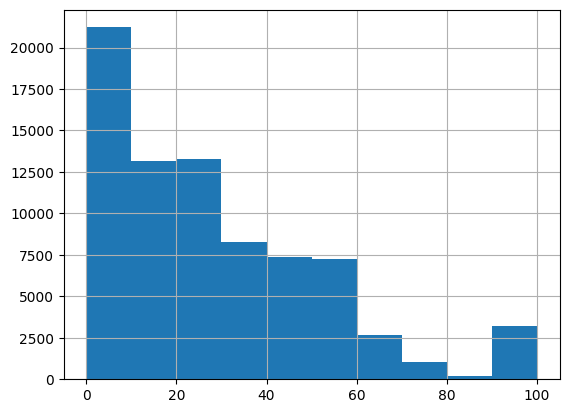

In [47]:
fichier_final_vote['voix_pct'].hist()

In [48]:
fichier_final_vote_ss_2008 = fichier_final_vote[(fichier_final_vote['annee']!= "2008") &
                                                    (fichier_final_vote['voix_pct'] > 50)
]

In [49]:
fichier_final_vote_ss_2008.head()

,id_election,ident_election_ville,Nom,Prénom,Nuance_muni,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee,Région siège,...,Nom Président,prenom,dep,Nuance_interco,nom,insee,siren_membre,dept,siren,raison_sociale
10655,2014_muni_t1,01005,PERNET,Pierre,LDIV,479.0,479.0,100.000000,2014,84 - Auvergne-Rhône-Alpes,...,grison,bernard,01,LDVD,grison,01005,210100053,01,200042497,CC Dombes Saône Vallée
10659,2014_muni_t1,01010,THIBOUD,Bernard,LDVD,292.0,520.0,56.153846,2014,84 - Auvergne-Rhône-Alpes,...,rannard,paul,74,NC,rannard,01010,210100103,74,200070852,CC Usses et Rhône
10661,2014_muni_t1,01014,MAISSIAT,Liliane,LUMP,930.0,930.0,100.000000,2014,84 - Auvergne-Rhône-Alpes,...,deguerry,jean,01,LDVD,deguerry,01014,210100145,01,200042935,CA Haut-Bugey Agglomération
10662,2014_muni_t1,01021,PACCAUD,Richard,LDIV,411.0,726.0,56.611570,2014,84 - Auvergne-Rhône-Alpes,...,grison,bernard,01,LDVD,grison,01021,210100210,01,200042497,CC Dombes Saône Vallée
10664,2014_muni_t1,01022,CHARMONT-MUNET,Mireille,LDVD,386.0,593.0,65.092749,2014,84 - Auvergne-Rhône-Alpes,...,vuillerod,rene,01,LREM,vuillerod,01022,210100228,01,200040350,CC Bugey Sud


In [50]:
fichier_final_vote_ss_2008.shape

(10127, 38)

In [51]:
table_code_insee_code_postal = pd.read_csv("/home/onyxia/work/projet3A/donnees_electorales/correspondance-code-insee-code-postal.csv", sep = ";", dtype='str')
table_code_insee_code_postal = table_code_insee_code_postal[['Code INSEE', 'Code Postal']]

In [52]:
fichier_vote_avec_code_postal = pd.merge(
fichier_final_vote_ss_2008,
table_code_insee_code_postal,
left_on = 'insee',
right_on = 'Code INSEE'
)

In [53]:
fichier_vote_avec_code_postal.head()

,id_election,ident_election_ville,Nom,Prénom,Nuance_muni,voix_totales_candidat,voix_total_ville_elec,voix_pct,annee,Région siège,...,dep,Nuance_interco,nom,insee,siren_membre,dept,siren,raison_sociale,Code INSEE,Code Postal
0,2014_muni_t1,01005,PERNET,Pierre,LDIV,479.0,479.0,100.000000,2014,84 - Auvergne-Rhône-Alpes,...,01,LDVD,grison,01005,210100053,01,200042497,CC Dombes Saône Vallée,01005,01330
1,2014_muni_t1,01010,THIBOUD,Bernard,LDVD,292.0,520.0,56.153846,2014,84 - Auvergne-Rhône-Alpes,...,74,NC,rannard,01010,210100103,74,200070852,CC Usses et Rhône,01010,01350
2,2014_muni_t1,01014,MAISSIAT,Liliane,LUMP,930.0,930.0,100.000000,2014,84 - Auvergne-Rhône-Alpes,...,01,LDVD,deguerry,01014,210100145,01,200042935,CA Haut-Bugey Agglomération,01014,01100
3,2014_muni_t1,01021,PACCAUD,Richard,LDIV,411.0,726.0,56.611570,2014,84 - Auvergne-Rhône-Alpes,...,01,LDVD,grison,01021,210100210,01,200042497,CC Dombes Saône Vallée,01021,01480
4,2014_muni_t1,01022,CHARMONT-MUNET,Mireille,LDVD,386.0,593.0,65.092749,2014,84 - Auvergne-Rhône-Alpes,...,01,LREM,vuillerod,01022,210100228,01,200040350,CC Bugey Sud,01022,01510


### vérifs des données

In [54]:
fichier_vote_avec_code_postal['id_election'].value_counts()

id_election
2014_muni_t1    5336
2020_muni_t1    2129
2020_muni_t2     454
2014_muni_t2     235
Name: count, dtype: int64

ici nombre de maire élus au premier tour en 2014
https://www.lemonde.fr/les-decodeurs/article/2014/03/24/qui-sont-les-maires-elus-des-le-premier-tour_4388664_4355770.html
Normalement 7606 dans les communes de + de 1000 habitants

In [55]:
fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2014_muni_t1'
]['Nuance_muni'].value_counts()

Nuance_muni
LDVD    2040
LDVG    1255
LDIV     991
LSOC     272
LUMP     218
LUG      183
LUD      140
LUDI     133
LCOM      44
LMDM      21
LUC       18
LFG       12
LVEC       4
LPG        3
LFN        1
LEXD       1
Name: count, dtype: int64

Il en manque

On exporte temporairement un fichier pas clean

In [56]:
fichier_vote_avec_code_postal_clean = fichier_vote_avec_code_postal[['annee',
'ident_election_ville', 'Nuance_muni','voix_pct','Nuance_interco']]

In [57]:
fichier_vote_avec_code_postal_clean[(fichier_vote_avec_code_postal_clean['voix_pct'] < 55)].shape

(1792, 5)

In [58]:
fichier_vote_avec_code_postal_clean.to_csv("/home/onyxia/work/projet3A/donnees_electorales/donnees_muni_epci_completes.csv", index=False)